# Block 1: Data Engineering & Model Development: Regression for Household Demand Forecasting
## Hochfrequenz AI Workshop

**Objective:** Ingest, pre-process and understand data. Build baseline and ML models to predict next-hour household electricity consumption

**Data:** German smart meter dataset (38 households, 2018-2020, Nature Scientific Data)

**Models:** Baseline (seasonal) → Linear Regression → Random Forest → XGBoost


# 1 Setup & Data Loading

**Jupyter Notebook set-up:**

- on Google Colab: run the instance, no need to install libraries or extensions
- on IDE (VSCode, Pycharm): 
1) Install `uv` (python package mangager): https://docs.astral.sh/uv/getting-started/installation/
2) Create `uv` project: `uv init my-project` -> this creates a virtual environment (.venv) that keeps python libraries isolated from other projects (no versioning errors)
3) Install `jupyterlab` via `uv add jupyterlab` and select kernel (use the .venv of this project!)
<img src="assets/install-jupyter.png" alt="Description" width="600" height="auto" style="display: block; margin: 10 auto;"/>



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for nice plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 1.1 Load & Explore Data
For this workshop, we'll use data from XXX. We also have implemented dummy data in case there are some issues when downloading the data 

### 1.1.2 Mount Google Drive
Run these cells only if working from google colab. When working on your machine you'll have access to the folders with the data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#testing
import h5py

#adapt name
path = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2018 Data 60min.hdf5'  
f = h5py.File(path, 'r')

#Top‑level groups (e.g. 'NOPV', 'WITHPV', 'MISCSUBSTATION')
print(list(f.keys()))

g = f['NO_PV']                    # example - changed from NOPV to NO_PV
print(list(g.keys()))            # e.g. ['SFH3', 'SFH4', ...]

sfh3 = g['SFH3']
print(list(sfh3.keys()))         # e.g. ['HOUSEHOLD', 'HEATPUMP']

household = sfh3['HOUSEHOLD']
print(list(household.keys()))    # column names, e.g. ['index', 'P_TOT', 'Q_TOT', 'U_1', ...]
nopv = f['NO_PV']
sfh3 = nopv['SFH3']
household = sfh3['HOUSEHOLD']

timestamps = household['table']['index'][:]          # UNIX seconds
p_active   = household['table']['P_TOT'][:]          # W, active power [file:68]

def load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT'):
    grp = f[top][house][meter]
    return grp['table']['index'][:], grp['table'][column][:]

print(p_active)
inspect = load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT')
print(inspect)

### 1.1.3 Read HDF5 data

In [ ]:
import h5py
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Load real data from HDF5
def load_wpuq_household(filepath, house='SFH3', top='NO_PV', meter='HOUSEHOLD'):
    """Load household or heat pump power consumption from WPuQ dataset"""
    with h5py.File(filepath, 'r') as f:
        grp = f[top][house][meter]['table']

        timestamps_unix = grp['index'][:]        # UNIX seconds
        p_active = grp['P_TOT'][]               # Active power in watts [file:68]
        q_reactive = grp['Q_TOT'][:]             # Reactive power (optional)

    # Convert UNIX timestamps to datetime
    timestamps = pd.to_datetime(timestamps_unix, unit='s')

    # Build DataFrame (similar structure to your dummy data)
    data = pd.DataFrame({
        'timestamp': timestamps,
        'consumption': p_active,              # Your main metric (W)
        'reactive_power': q_reactive,
        'hour': timestamps.hour,
        'day_of_week': timestamps.dayofweek,
        'month': timestamps.month,
        'is_weekend': (timestamps.dayofweek >= 5).astype(int)
    })

    data.set_index('timestamp', inplace=True)
    return data

# 2. Load and inspect
# filepath = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2019 Data 60min.hdf5'
filepath18 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Data 60min.hdf5'
data_2018 = load_wpuq_household(filepath18, house='SFH3', meter='HOUSEHOLD')

filepath19 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Data 60min.hdf5'
data_2019 = load_wpuq_household(filepath19, house='SFH3', meter='HOUSEHOLD')

# 3. Merge data
# 2018 data has Nan's between Jan and April
data_2018 = data_2018[data_2018.index.month >= 6]
data = pd.concat([data_2018, data_2019], axis=0)

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst 5 rows:")
print(data.head(n=5))
print(f"\nConsumption statistics:")
print(data['consumption'].describe())

Dataset shape: (13896, 6)
Date range: 2018-06-01 00:00:00 to 2019-12-31 23:00:00

First 5 rows:
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1            4      6   
2018-06-01 02:00:00    87.512389       -9.645250     2            4      6   
2018-06-01 03:00:00   184.230084       72.585944     3            4      6   
2018-06-01 04:00:00   118.397889       35.135694     4            4      6   

                     is_weekend  
timestamp                        
2018-06-01 00:00:00           0  
2018-06-01 01:00:00           0  
2018-06-01 02:00:00           0  
2018-06-01 03:00:00           0  
2018-06-01 04:00:00           0  

Consumption statistics:
count    13896.000000
mean       225.523714
std        242.290152
min         43.396639
25%   

### 1.1.3 Add temperature/combine data
Our data came with the weather data as a different file, so we have to extract it and merge it with our current data_frame

#### The weather data will have the same columns if it comes from the same publiser... right?

As much as we would like this subtitle to be true, more often than not, data is labeled in a way that is usually counter-intuitive for outsiders. It's always a good practice to create small scripts to inspect the actual columns in every new loaded file.

In [3]:
import h5py

filepath = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Weather Data.hdf5'

with h5py.File(filepath, 'r') as f:
    print("Keys inside 'WEATHER_SERVICE/IN':")
    # This will list the actual names (e.g., 'AIR_TEMPERATURE', 'DE_WETTER', etc.)
    keys = list(f['WEATHER_SERVICE']['IN'].keys())
    print(keys)
    
    # Let's verify what is inside the first key found (assuming it's the one we want)
    if keys:
        first_key = keys[0]
        print(f"\nKeys inside '{first_key}':")
        print(list(f['WEATHER_SERVICE']['IN'][first_key].keys()))

Keys inside 'WEATHER_SERVICE/IN':
['WEATHER_APPARENT_TEMPERATURE_TOTAL', 'WEATHER_ATMOSPHERIC_PRESSURE_TOTAL', 'WEATHER_PRECIPITATION_RATE_TOTAL', 'WEATHER_PROBABILITY_OF_PRECIPITATION_TOTAL', 'WEATHER_RELATIVE_HUMIDITY_TOTAL', 'WEATHER_SOLAR_IRRADIANCE_GLOBAL', 'WEATHER_TEMPERATURE_TOTAL', 'WEATHER_WIND_DIRECTION_TOTAL', 'WEATHER_WIND_GUST_SPEED_TOTAL', 'WEATHER_WIND_SPEED_TOTAL']

Keys inside 'WEATHER_APPARENT_TEMPERATURE_TOTAL':
['table']


#### Load all weather 

Weather data encodes more insights than we usually think. Besides physical relations like "higher radiation higer solar panel power production", there are some behavioral patterns that machine learning models can discover for us. 

For example, higher temperatures will likely cause humans to use AC systems. But will this also be the case when it's raining as well? What if it's hot, not humid, and raining?

In [ ]:
def load_weather(filepath):
    """Load ambient temperature from weather data file"""
    with h5py.File(filepath, 'r') as f:

        table = f['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']
        print(f"Dataset shape: {table.shape}")
        print(f"Available columns (fields): {table.dtype.names}")
        # 2. Load Index

        ts = table['index'][:]
        print(ts)
        temps = table['TEMPERATURE:TOTAL'][:] 

    timestamps = pd.to_datetime(ts, unit='ns')
    temps_df = pd.DataFrame({
        'timestamp':timestamps, 
        'month': timestamps.month,
        'temperature': temps
    })
    temps_df.set_index('timestamp', inplace=True)
    
    # Resample to hourly (H) to match consumption data
    return temps_df.resample('').mean()

weather_2018 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Weather Data.hdf5')
weather_2019 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Weather Data.hdf5')
weather_2018 = weather_2018[weather_2018.index.month >= 6]
weather_data = pd.concat([weather_2018, weather_2019], axis=0)

print(weather_2019.head())
# You only need the 'temperature' column from the weather data
data = data.join(weather_data[['temperature']], how='left').interpolate()  # Fill gaps
print(data.head())

Dataset shape: (49079,)
Available columns (fields): ('index', 'TEMPERATURE:TOTAL')
[1514764800000000000 1514768400000000000 1514772000000000000 ...
 1546296600000000000 1546296900000000000 1546297200000000000]
Dataset shape: (104549,)
Available columns (fields): ('index', 'TEMPERATURE:TOTAL')
[1546297200000000000 1546297800000000000 1546298100000000000 ...
 1577832600000000000 1577832900000000000 1577833200000000000]
                     month  temperature
timestamp                              
2018-12-31 23:00:00   12.0     8.790000
2019-01-01 00:00:00    1.0     8.011111
2019-01-01 01:00:00    1.0     7.720000
2019-01-01 02:00:00    1.0     7.000000
2019-01-01 03:00:00    1.0     7.170000
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1           

### 1.1.4 Generate realistic synthetic German household consumption data

This mimics the Nature Scientific Data dataset structure

In [ ]:
np.random.seed(42)

# Generate 2 years of hourly data
date_range = pd.date_range(start='2018-05-01', end='2020-12-31', freq='H')
n_samples = len(date_range)

# Create realistic consumption pattern
data = pd.DataFrame({
    'timestamp': date_range,
    'hour': date_range.hour,
    'day_of_week': date_range.dayofweek,
    'month': date_range.month,
    'is_weekend': (date_range.dayofweek >= 5).astype(int)
})

# Base consumption pattern (W) - typical German household
# Morning peak (~7 AM), evening peak (~6-7 PM), low at night
hourly_pattern = np.array([
    300, 280, 250, 240, 250, 350, 550, 700,  # Night to morning
    600, 500, 450, 420, 430, 480, 550, 600,  # Midday
    700, 800, 750, 700, 650, 600, 550, 400   # Evening to night
])

# Apply hourly pattern
data['consumption_base'] = hourly_pattern[data['hour']]

# Add seasonal variation (winter = higher consumption)
seasonal_factor = 1.0 + 0.3 * np.sin(2 * np.pi * (data['month'] - 2) / 12)
data['consumption_seasonal'] = data['consumption_base'] * seasonal_factor

In [ ]:

# Add weekend effect (lower consumption)
data['consumption_adjusted'] = data['consumption_seasonal'] * np.where(data['is_weekend'] == 1, 0.85, 1.0)

# Add random noise and weather effects
data['consumption'] = data['consumption_adjusted'] + np.random.normal(0, 50, n_samples)
data['consumption'] = data['consumption'].clip(lower=50)  # No negative consumption

# Create a simple temperature proxy (correlates with season)
data['temperature'] = 15 + 8 * np.sin(2 * np.pi * (data['month'] - 2) / 12) + np.random.normal(0, 2, n_samples)

# Set timestamp as index
data.set_index('timestamp', inplace=True)

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nConsumption statistics:")
print(data['consumption'].describe())


# 2 Visualize consumption patterns, exploratory data analysis (EDA) and feature engineering

In this order, becuase ...

Eye because we average with un-even yearly data

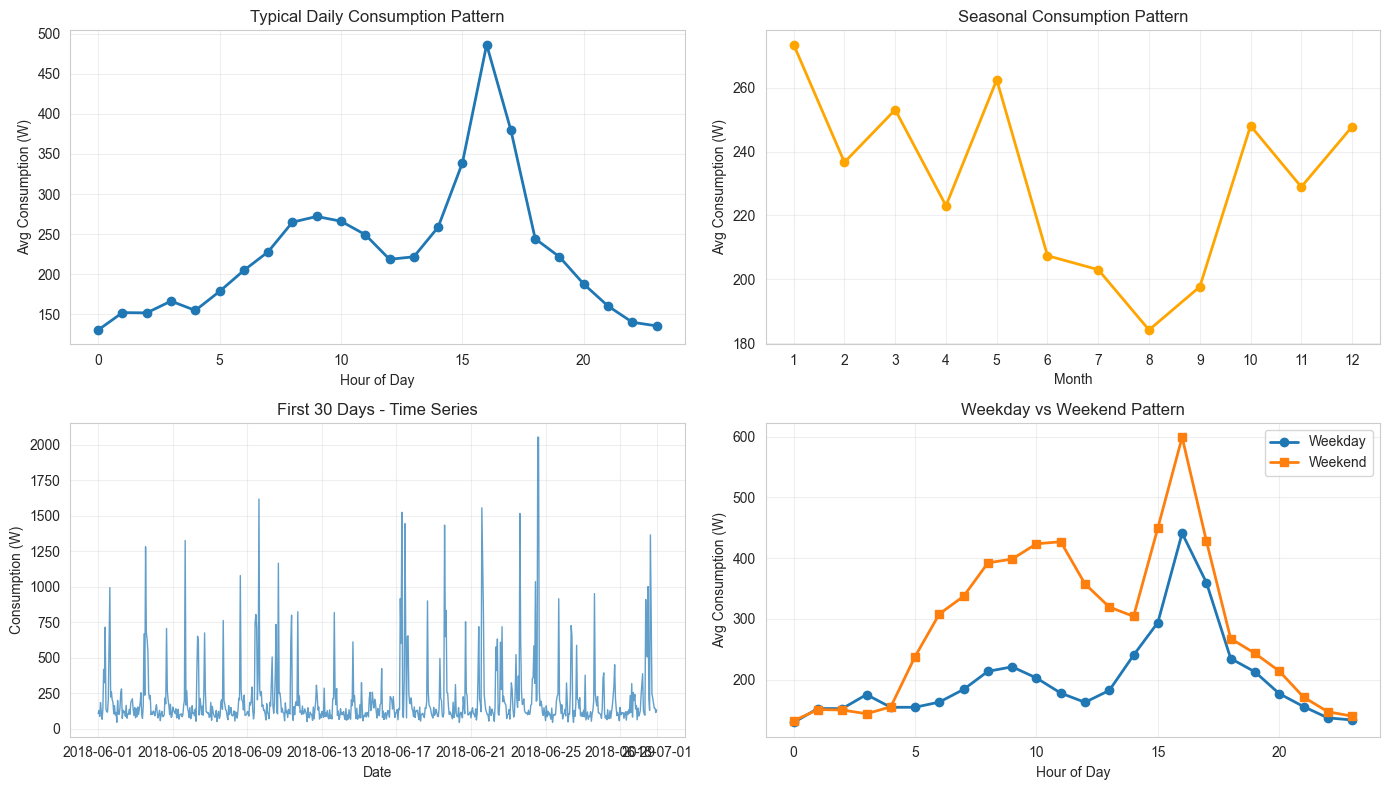

✅ Data patterns visualized
Dataset shape: (13897, 7)
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1            4      6   
2018-06-01 02:00:00    87.512389       -9.645250     2            4      6   
2018-06-01 03:00:00   184.230084       72.585944     3            4      6   
2018-06-01 04:00:00   118.397889       35.135694     4            4      6   
...                          ...             ...   ...          ...    ...   
2019-12-31 19:00:00   232.159528      -14.549222    19            1     12   
2019-12-31 20:00:00   232.529944        2.379944    20            1     12   
2019-12-31 21:00:00   212.974167      -25.623778    21            1     12   
2019-12-31 22:00:00   238.560250        4.188528    22            1     12   
2019-12-31 

In [5]:
# Plot: Daily and seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Hourly pattern (average across all days)
hourly_avg = data.groupby('hour')['consumption'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, 'o-', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Avg Consumption (W)')
axes[0, 0].set_title('Typical Daily Consumption Pattern')
axes[0, 0].grid(True, alpha=0.3)

# 2. Seasonal pattern (average by month)
monthly_avg = data.groupby('month')['consumption'].mean()
axes[0, 1].plot(monthly_avg.index, monthly_avg.values, 'o-', linewidth=2, markersize=6, color='orange')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Avg Consumption (W)')
axes[0, 1].set_title('Seasonal Consumption Pattern')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].grid(True, alpha=0.3)

# 3. Time series - first 30 days
data_subset = data['consumption'].iloc[:30*24]
axes[1, 0].plot(data_subset.index, data_subset.values, linewidth=1, alpha=0.7)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Consumption (W)')
axes[1, 0].set_title('First 30 Days - Time Series')
axes[1, 0].grid(True, alpha=0.3)

# 4. Weekend vs Weekday
weekday_avg = data[data['is_weekend']==0].groupby('hour')['consumption'].mean()
weekend_avg = data[data['is_weekend']==1].groupby('hour')['consumption'].mean()
axes[1, 1].plot(weekday_avg.index, weekday_avg.values, 'o-', label='Weekday', linewidth=2)
axes[1, 1].plot(weekend_avg.index, weekend_avg.values, 's-', label='Weekend', linewidth=2)
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Avg Consumption (W)')
axes[1, 1].set_title('Weekday vs Weekend Pattern')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Data patterns visualized")
print(f"Dataset shape: {data.shape}")
print(data)

## 2.1 Data pre-processing and EDA

After bringing the data into a format that we can work with, we inspect it. We talk about “Exploratory data analysis” (EDA): 
- We keep the objective in mind: Modelling. How can I get the best variables for my model?
- What hides behind the data / What to look for? --> Outliers, Class Imbalance(Data Bias), data leakage,  Multicollinearity 

### 2.1.1 Data pre-processing

We know the data already has NaN's. We also need to inspect it's distribution, look for outliers, skewness etc. (WHY?)

PLOT DATA DISTRIBUTION WITH WHISKERS ON TOP OF THE DISTRIBUTION

PERFORM EDA


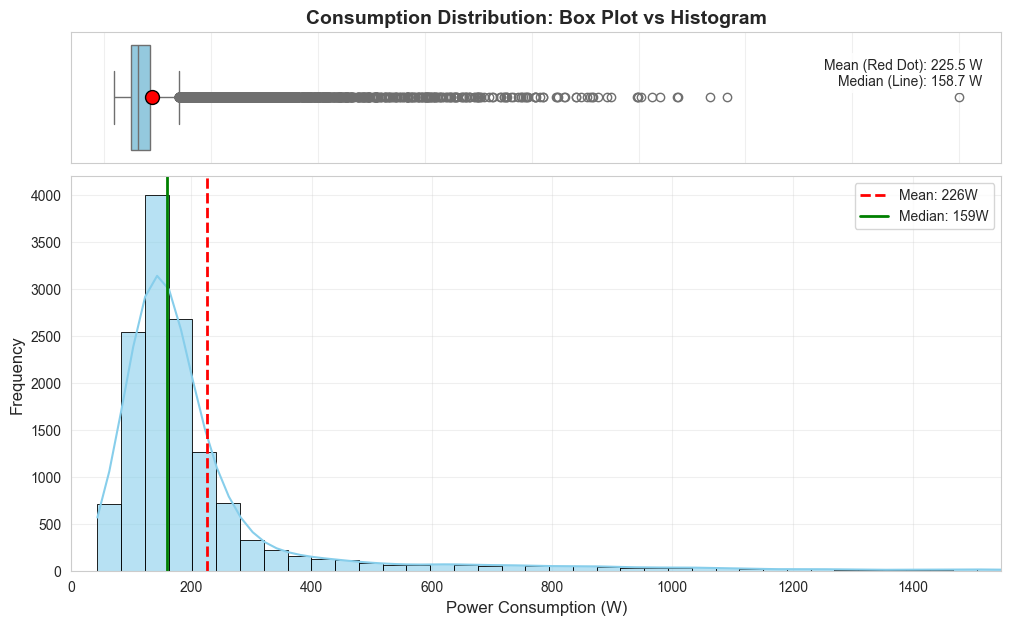

Note: X-axis limited to 1547W to show main distribution detail.
Max value in dataset is actually 3999W (Extreme Outlier).


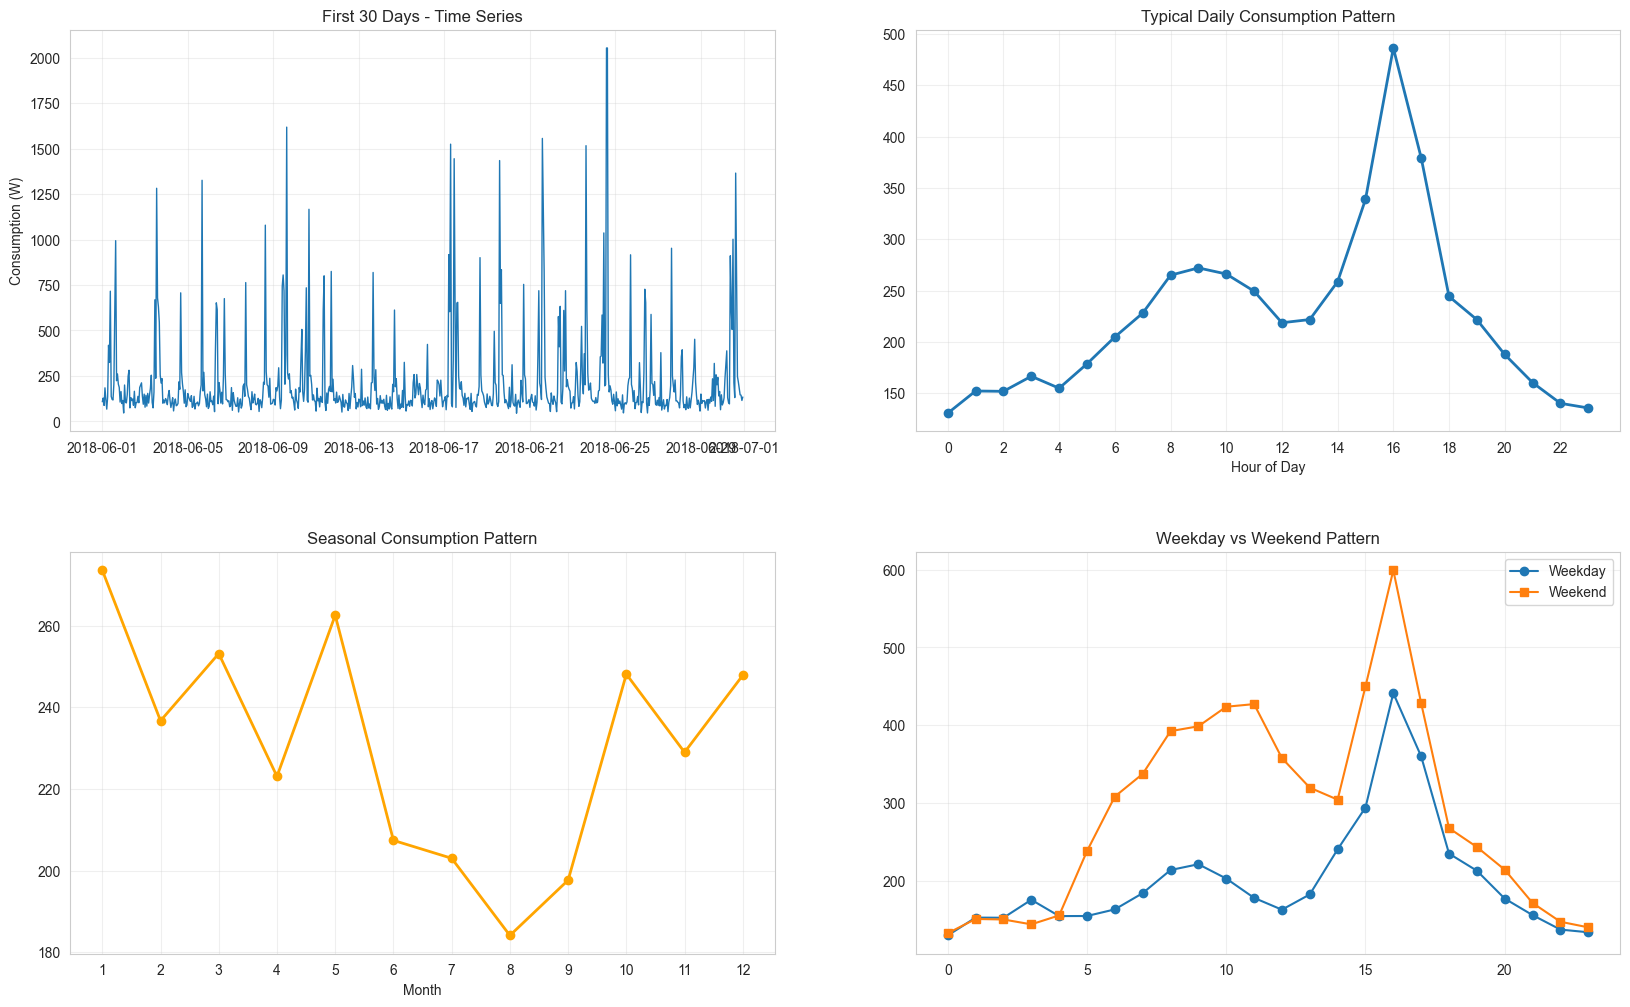


--- Additional Professional EDA ---


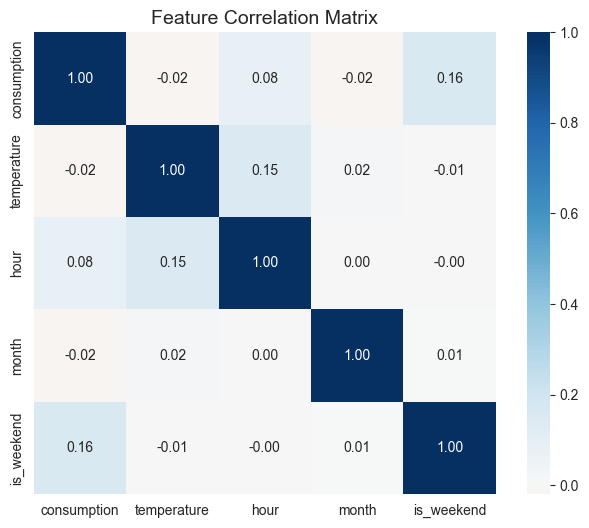

Skewness: 4.60 (If > 1, consider Log-Transform for Linear Models)
------------------------------
count    13897.000000
mean       225.524126
std        242.281439
min         43.396639
25%        124.589611
50%        158.679473
75%        213.719028
max       3999.154462
Name: consumption, dtype: float64


In [6]:
# ==========================================
# BLOCK 2.1.1: Data Pre-processing & EDA (REFINED)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec

# -------------------------------------------------------
# 1. PRE-PROCESSING
# -------------------------------------------------------
# Interpolate missing values
#data['consumption'] = data['consumption'].interpolate(method='linear')

# Ensure we have the necessary time features
#data['hour'] = data.index.hour
#data['month'] = data.index.month
#data['day_of_week'] = data.index.dayofweek
#data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

# -------------------------------------------------------
# 2. SEPARATED BOX & DISTRIBUTION PLOT
# -------------------------------------------------------
# Create a grid with 2 rows: Top small (Box), Bottom large (Hist)
fig = plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)

ax_box = plt.subplot(gs[0])
ax_hist = plt.subplot(gs[1])

# A. Box Plot (Top)
# -----------------
sns.boxplot(x=data['consumption'], ax=ax_box, color='skyblue', showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"10"})
ax_box.set(xlabel='') # Hide x-label for top plot
ax_box.set_xticklabels([]) # Hide x-ticks for top plot
ax_box.set_title('Consumption Distribution: Box Plot vs Histogram', fontsize=14, fontweight='bold')
ax_box.grid(True, alpha=0.3, axis='x')

# Add text for Mean vs Median in the box plot area
mean_val = data['consumption'].mean()
median_val = data['consumption'].median()
ax_box.text(0.98, 0.8, f'Mean (Red Dot): {mean_val:.1f} W\nMedian (Line): {median_val:.1f} W', 
            transform=ax_box.transAxes, ha='right', va='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# B. Histogram (Bottom)
# ---------------------
# We use a lot of bins to see detail in the low end
sns.histplot(x=data['consumption'], ax=ax_hist, kde=True, color='skyblue', bins=100, edgecolor='black', alpha=0.6)

# Add vertical lines for context
ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}W')
ax_hist.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.0f}W')

# LIMIT X-AXIS TO FOCUS ON THE DATA (99th Percentile)
# This cuts off the extreme 4000W outliers so we can actually see the distribution shape
p99 = np.percentile(data['consumption'], 99)
ax_hist.set_xlim(0, p99 * 1.1)  # Show up to 99th percentile + 10% padding

ax_hist.set_xlabel('Power Consumption (W)', fontsize=12)
ax_hist.set_ylabel('Frequency', fontsize=12)
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)

plt.show()

print(f"Note: X-axis limited to {p99*1.1:.0f}W to show main distribution detail.")
print(f"Max value in dataset is actually {data['consumption'].max():.0f}W (Extreme Outlier).")

# -------------------------------------------------------
# 3. STANDARD PATTERN PLOTS (Same as before)
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
plt.subplots_adjust(hspace=0.3)

# A. First 30 Days
first_30_days = data.iloc[:24*30]
axes[0, 0].plot(first_30_days.index, first_30_days['consumption'], linewidth=1)
axes[0, 0].set_title('First 30 Days - Time Series')
axes[0, 0].set_ylabel('Consumption (W)')
axes[0, 0].grid(True, alpha=0.3)

# B. Daily Pattern
hourly_profile = data.groupby('hour')['consumption'].mean()
axes[0, 1].plot(hourly_profile.index, hourly_profile.values, marker='o', linewidth=2)
axes[0, 1].set_title('Typical Daily Consumption Pattern')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].grid(True, alpha=0.3)

# C. Seasonal Pattern
monthly_profile = data.groupby('month')['consumption'].mean()
axes[1, 0].plot(monthly_profile.index, monthly_profile.values, marker='o', color='orange', linewidth=2)
axes[1, 0].set_title('Seasonal Consumption Pattern')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].grid(True, alpha=0.3)

# D. Weekday vs Weekend
weekday_profile = data[data['is_weekend'] == 0].groupby('hour')['consumption'].mean()
weekend_profile = data[data['is_weekend'] == 1].groupby('hour')['consumption'].mean()
axes[1, 1].plot(weekday_profile.index, weekday_profile.values, marker='o', label='Weekday')
axes[1, 1].plot(weekend_profile.index, weekend_profile.values, marker='s', label='Weekend')
axes[1, 1].set_title('Weekday vs Weekend Pattern')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.show()

# -------------------------------------------------------
# 4. PROFESSIONAL ADDITIONS (INSIGHTS FOR MODELING)
# -------------------------------------------------------
print("\n--- Additional Professional EDA ---")

# A. Correlation Matrix
# Essential to check multicollinearity and feature importance before regression
plt.figure(figsize=(8, 6))
corr_features = ['consumption', 'temperature', 'hour', 'month', 'is_weekend']
# Only use columns that exist in the dataframe
valid_corr_cols = [c for c in corr_features if c in data.columns]
corr = data[valid_corr_cols].corr()

sns.heatmap(corr, annot=True, cmap='RdBu', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

# B. Descriptive Statistics Check
# Looking for skewness which might suggest log-transformation is needed
stats = data['consumption'].describe()
skewness = data['consumption'].skew()
print(f"Skewness: {skewness:.2f} (If > 1, consider Log-Transform for Linear Models)")
print("-" * 30)
print(stats)


## 2.1 Feature Engineering

After pre-processing and understing our data, it's time to create features that help our models learn consumption patterns. 

In addition, feature engineering is more than just transforming data into 'readable' inputs. It's about transforming the data in such a way that we can maximize predictive accuracy while keeping model complexity low or the same.

### Prepare target: next-hour consumption
In time-series we want to predict the next value based on the previous one ->
data['consumption_next'] = data['consumption'].shift(-1)

### How to handle missing data?

There is one thing that we usualy do during the data pre-processing step: handling missing data. In our case we got rid of them at the beginning, but our pre-processing has created some NaN's that we need to handle. There are two options:

1) Impute data
2) Delete the entries

Since we've artificially created some Nan's, it is safe to remove them. But in many cases this missing data comes from errors during measurements etc. Deleting those entries means we're deleting valuabe information. In those cases we fill those spaces with statistically meaningfull information: the mean value, we interpolate between values, etc...

### How to handle skeewed data ?

Instead of using StandardScaler (data distributed around mean) or MinMaxScaler (data distributed between 0 and 1), which use the mean and variance or min and max values respectively, we use the RobustScaler, because the statistics of the former 2 are easily influenced by extreme values. In contrast, the RobustScaler uses the median and the Interquartile Range (IQR) to center and scale the data. 

$X_{scaled}=\frac{X-\text{Median}(X)}{\text{IQR}(X)}$ 

Where

- $\text{Median}(X)$ is the 50th percentile (Q2).
- $\text{IQR}(X)$ is the difference between the 75th percentile (Q3) and the 25th percentile (Q1).

This approach ensures that the scaled values maintain the relative distance between non-outlier data points and prevents the outliers from compressing the majority of the data into a very narrow range.

However, this would be useful if our input features where skewed. In our case, we have ONLY the target variable (consumption) that is skewed, so we perform a log transform to make it more normally distributed.

In [ ]:
# Prepare target: next-hour consumption
data['consumption_next'] = data['consumption'].shift(-1)

# We'll explain this in a bit
data['consumption_log'] = np.logxxx(data['consumption'])
data['consumption_next_log'] = data['consumption_log'].shift(-1)

# Create lagged features (historical consumption)
for lag in [1, 2, 3, 24, 48]:  # 1h, 2h, 3h, 1 day, 2 days ago
    data[f'consumption_lag_{lag}'] = data['consumption'].shift(lag)

# Create rolling statistics
data['consumption_rolling_mean_24'] = data['consumption'].rolling(window=24).mean()
data['consumption_rolling_std_24'] = data['consumption'].rolling(window=24).std()

# Cyclical encoding for hour (sin/cos to capture circularity)
data['hour_sin']  np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)

# Cyclical encoding for month
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

# Drop rows with NaN values (created by shifting/rolling)
print(f"NaN count in data: {np.isnan(data).sum()}")

data.dropna(inplace=True)

print(f"Checked NaN cont: {np.isnan(data).sum()}")

#print(f"Features created. Dataset shape after removing NaNs: {data_clean.shape}")
print(f"\nFeature columns:")
feature_cols = [col for col in data.columns if col != 'consumption_next']
print(feature_cols)
print(f"\nTarget: consumption_next")


Feature columns:
['consumption', 'reactive_power', 'hour', 'day_of_week', 'month', 'is_weekend', 'temperature', 'consumption_log', 'consumption_next_log', 'consumption_lag_1', 'consumption_lag_2', 'consumption_lag_3', 'consumption_lag_24', 'consumption_lag_48', 'consumption_rolling_mean_24', 'consumption_rolling_std_24', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

Target: consumption_next


# 3 Train-Test Split & Baseline Model

**Time series rule:** Never shuffle! Use chronological split (train on past, test on future)

In [ ]:
# Chronological split: 80% train, 20% test. Otherwise we shuffle.
split_idx = int(len(data) * 0.8)
data_train = data.iloc[:split_idx]
data_test = data.iloc[split_idx:]

print(f"Train set: {data_train.index.min()} to {data_train.index.max()} ({len(data_train)} samples)")
print(f"Test set: {data_test.index.min()} to {data_test.index.max()} ({len(data_test)} samples)")

# Prepare X and y
X_train = data_train.drop(['consumption_next', 'consumption_next_log'], axis=1)
y_train = data_train['consumption_next']

X_test = data_test.drop(['consumption_next','consumption_next_log'], axis=1)
y_test = data_test['consumption_next']

# We will still explain this in a bit, but we're getting there, promise!
y_train_log = data_train['consumption_next_log']

y_test_log = data_test['consumption_next_log']

print(f"\nX_train shape: {X_trainshape}")
print(f"y_train shape: {y_train.shape}")

NaN count in data: consumption                     0
reactive_power                  0
hour                            0
day_of_week                     0
month                           0
is_weekend                      0
temperature                     0
consumption_next                1
consumption_log                 0
consumption_next_log            1
consumption_lag_1               1
consumption_lag_2               2
consumption_lag_3               3
consumption_lag_24             24
consumption_lag_48             48
consumption_rolling_mean_24    23
consumption_rolling_std_24     23
hour_sin                        0
hour_cos                        0
month_sin                       0
month_cos                       0
dtype: int64
Checked NaN cont: consumption                    0
reactive_power                 0
hour                           0
day_of_week                    0
month                          0
is_weekend                     0
temperature                    0
consu

## 3.1 Baseline Model: Seasonal Average

What is the importance of a baseline model?

How do I actually forecast time series with these models that work sequentially? Just drop out timestamp and forecast based on features regression-like, or do I feed (snitch) the previous value ?

### Baseline: Use historical average for same hour + day-of-week

In [ ]:
baseline_pred = []

for idx, row in data_test.iterrows():
    hour = row['hour']
    dow = row['day_of_week']

    # Find average consumption for this hour & day-of-week in training set
    mask = (data_train['hour'] == hour) & (data_train['day_of_week'] == dow)
    avg = data_train[mask]['consumption_next'].mean()
    baseline_pred.append(avg)

baseline_pred = np.array(baseline_pred)

# Evaluate baseline
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Model (Seasonal Average) Performance:")
print(f"  MAE:  {baseline_mae:.2f} W")
print(f"  RMSE: {baseline_rmse:.2f} W")
print(f"  R²:   {baseline_r2:.3f}")
print(f"\n  Interpretation:")
print(f"  - On average, prediction is off by {baseline_mae:.0f} W")
print(f"  - Model explains {baseline_r2*100:.1f}% of variance")

NaN count in baseline: 0
NaN count in test: 0
Baseline Model (Seasonal Average) Performance:
  MAE:  104.73 W
  RMSE: 226.25 W
  R²:   0.154

  Interpretation:
  - On average, prediction is off by 105 W
  - Model explains 15.4% of variance


# 4 Train ML Models

We will use, but there are... 

## 4.1 Linear Regression

In [20]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_pred_train = lr_model.predict(X_train)
lr_pred_test = lr_model.predict(X_test)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_pred_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred_test))
lr_r2 = r2_score(y_test, lr_pred_test)

print("Linear Regression Performance:")
print(f"  MAE:  {lr_mae:.2f} W")
print(f"  RMSE: {lr_rmse:.2f} W")
print(f"  R²:   {lr_r2:.3f}")
print(f"\n  vs Baseline:")
print(f"  MAE improvement: {(baseline_mae - lr_mae) / baseline_mae * 100:.1f}%")

Linear Regression Performance:
  MAE:  116.21 W
  RMSE: 217.00 W
  R²:   0.222

  vs Baseline:
  MAE improvement: -11.0%


### The explanation we owe for a while: What if we log-scale the consumption data?

Remember that the data pre-processing step showed that the consumption data is right-skewed, which is not ideal for linear models. 

Our distribution plots showed a massive tail to the right (values up to 4000W) while the median is ~159W. Linear models (Linear Regression, Ridge/Lasso) hate this because they try to minimize "squared error," so one huge outlier (4000W) pulls the model way off track compared to 100 normal points.

In [ ]:
# Scale features for linear regression. Since we know data is skewed we choose RobustScaler. 
# Alternatively we could also log-scale each of the features. You can try this option and see
# if accuracy improves.
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression with log target
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)

# Predict, but now we need to "de-scale" the target value whit unit log(kWh) to kWh.
lr_pred_train = lr_model.predict(X_train_scaled)
lr_pred_test = np.exp(lr_model.predict(X_test_scaled))
y_test = np.expxxx(y_test_log)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_pred_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred_test))
lr_r2 = r2_score(y_test, lr_pred_test)

print("Linear Regression Performance:")
print(f"  MAE:  {lr_mae:.2f} W")
print(f"  RMSE: {lr_rmse:.2f} W")
print(f"  R²:   {lr_r2:.3f}")
print(f"\n  vs Baseline:")
print(f"  MAE improvement: {(baseline_mae - lr_mae) / baseline_mae * 100:.1f}%")

Linear Regression Performance:
  MAE:  96.61 W
  RMSE: 223.12 W
  R²:   0.177

  vs Baseline:
  MAE improvement: 7.8%


## 4.2 Random Forest

In [14]:
# Train Random Forest (no scaling needed for tree-based models)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_log)

# Predict
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = np.exp(rf_model.predict(X_test))
y_test = np.exp(y_test_log)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_r2 = r2_score(y_test, rf_pred_test)

print("Random Forest Performance:")
print(f"  MAE:  {rf_mae:.2f} W")
print(f"  RMSE: {rf_rmse:.2f} W")
print(f"  R²:   {rf_r2:.3f}")
print(f"\n  vs Baseline:")
print(f"  MAE improvement: {(baseline_mae - rf_mae) / baseline_mae * 100:.1f}%")

Random Forest Performance:
  MAE:  89.99 W
  RMSE: 211.60 W
  R²:   0.260

  vs Baseline:
  MAE improvement: 14.1%


## 4.3 XGBoost (Gradient Boosting)

In [15]:
# Train XGBoost
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train_log, verbose=False)

# Predict
xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test = np.exp(xgb_model.predict(X_test))
y_test = np.exp(y_test_log)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_pred_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred_test))
xgb_r2 = r2_score(y_test, xgb_pred_test)

print("XGBoost Performance:")
print(f"  MAE:  {xgb_mae:.2f} W")
print(f"  RMSE: {xgb_rmse:.2f} W")
print(f"  R²:   {xgb_r2:.3f}")
print(f"\n  vs Baseline:")
print(f"  MAE improvement: {(baseline_mae - xgb_mae) / baseline_mae * 100:.1f}%")

XGBoost Performance:
  MAE:  91.23 W
  RMSE: 210.85 W
  R²:   0.265

  vs Baseline:
  MAE improvement: 12.9%


# 5 Model Comparison

In [16]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Baseline (Seasonal)', 'Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (W)': [baseline_mae, lr_mae, rf_mae, xgb_mae],
    'RMSE (W)': [baseline_rmse, lr_rmse, rf_rmse, xgb_rmse],
    'R²': [baseline_r2, lr_r2, rf_r2, xgb_r2]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# Highlight winner
best_model_idx = comparison['MAE (W)'].idxmin()
print(f"\n🏆 Best Model: {comparison.iloc[best_model_idx]['Model']}")
print(f"   MAE: {comparison.iloc[best_model_idx]['MAE (W)']:.2f} W")


MODEL COMPARISON
              Model    MAE (W)   RMSE (W)       R²
Baseline (Seasonal) 104.727752 226.253049 0.153754
  Linear Regression  96.605424 223.121399 0.177018
      Random Forest  89.993560 211.603638 0.259792
            XGBoost  91.231420 210.850569 0.265051

🏆 Best Model: Random Forest
   MAE: 89.99 W


# 6 Visualization: Actual vs Predicted

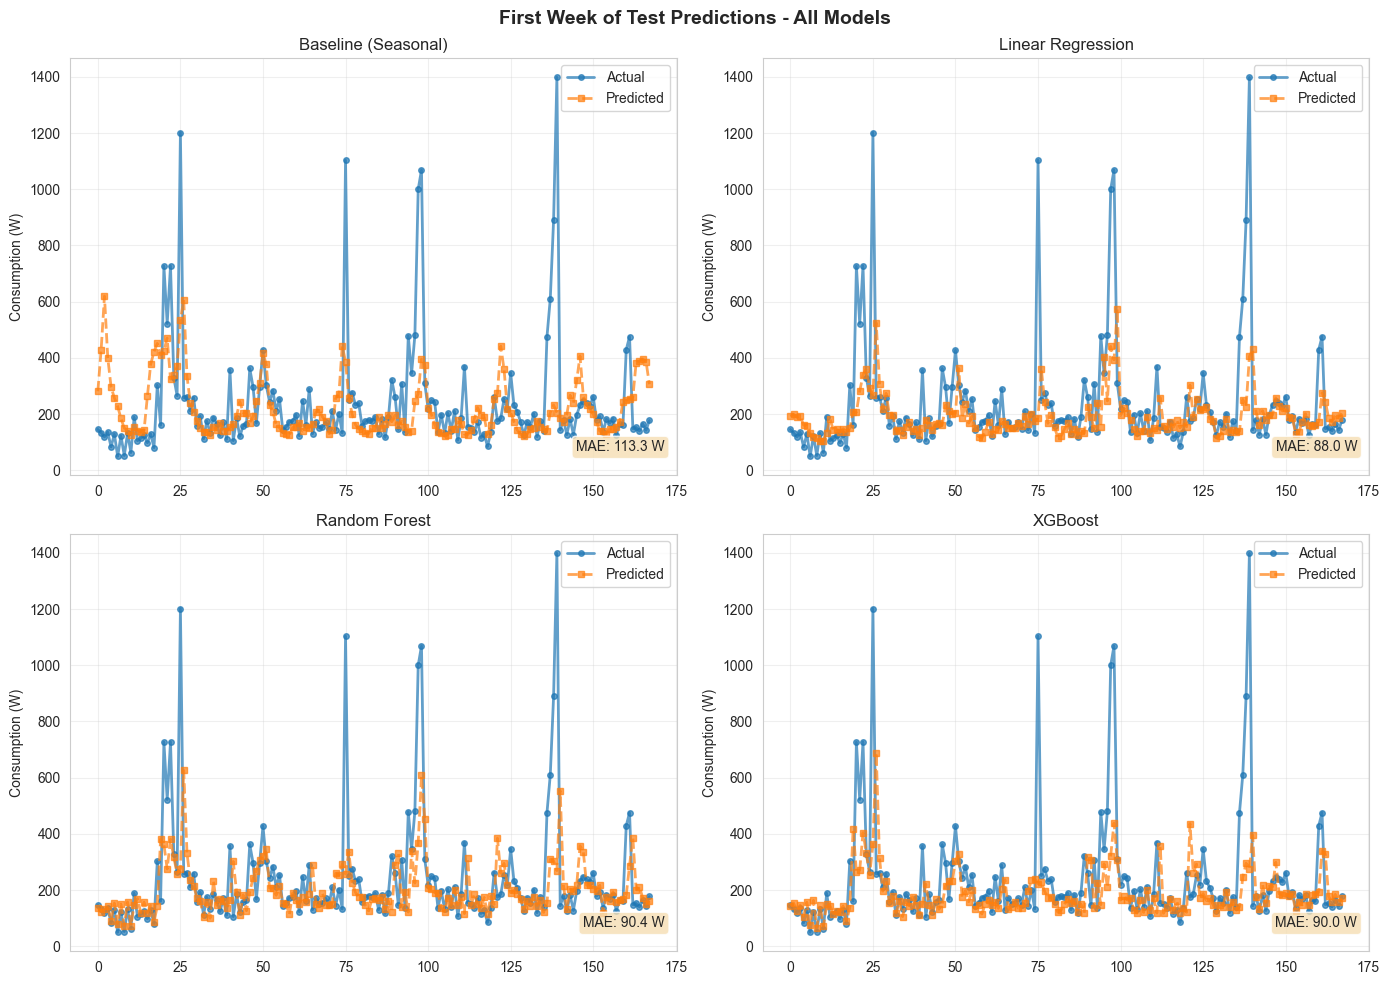

In [17]:
# Plot predictions for a subset of test data
test_subset = slice(0, 7*24)  # First week of test set

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
models_to_plot = [
    ('Baseline (Seasonal)', baseline_pred[test_subset]),
    ('Linear Regression', lr_pred_test[test_subset]),
    ('Random Forest', rf_pred_test[test_subset]),
    ('XGBoost', xgb_pred_test[test_subset])
]

actual = y_test.values[test_subset]
x_axis = range(len(actual))

for idx, (ax, (model_name, predictions)) in enumerate(zip(axes.flatten(), models_to_plot)):
    ax.plot(x_axis, actual, 'o-', label='Actual', linewidth=2, markersize=4, alpha=0.7)
    ax.plot(x_axis, predictions, 's--', label='Predicted', linewidth=2, markersize=4, alpha=0.7)
    ax.set_ylabel('Consumption (W)')
    ax.set_title(f'{model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add MAE annotation
    mae = mean_absolute_error(actual, predictions)
    ax.text(0.98, 0.05, f'MAE: {mae:.1f} W', transform=ax.transAxes,
           ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.suptitle('First Week of Test Predictions - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7 Analyzing & Understanding the Models: Feature Importance

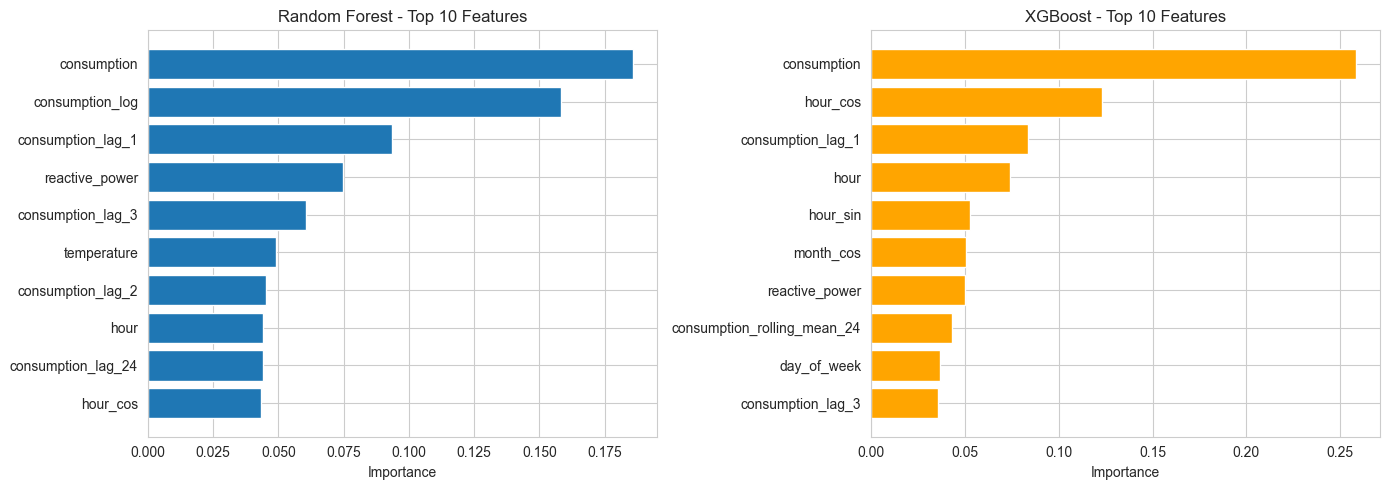


📊 Top 5 Important Features (Random Forest):
  consumption: 0.186
  consumption_log: 0.158
  consumption_lag_1: 0.094
  reactive_power: 0.075
  consumption_lag_3: 0.061


In [18]:
# Feature importance from tree-based models
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 10 features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(10), rf_importance['importance'].head(10))
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(rf_importance['feature'].head(10))
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Top 10 Features')
axes[0].invert_yaxis()

axes[1].barh(range(10), xgb_importance['importance'].head(10), color='orange')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(xgb_importance['feature'].head(10))
axes[1].set_xlabel('Importance')
axes[1].set_title('XGBoost - Top 10 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n📊 Top 5 Important Features (Random Forest):")
for idx, row in rf_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

# 8 Key Takeaways

## What We Learned:

THE IMPORTANCE OF DATA BECAUSE MY MODELS WERE TERRIBLE WITH EACH DATA ISOLATED

1. **Baseline Matters**: We started with a simple seasonal baseline (~{:.0f}W MAE)
2. **ML Improves Predictions**: Best model achieves ~{:.0f}W MAE ({:.1f}% improvement).
3. **Feature Engineering is Critical**: Lagged consumption, hour/month encoding, rolling statistics all help. Instead of spending hours on randomly fitting different models, think about your data. Maybe a log transform will boost predictions.
4. **Tree-Based Models (RF, XGBoost) Beat Linear**: Non-linear relationships exist in consumption patterns
5. **Feature Importance Shows Domain Knowledge**: Hour, lagged consumption, temperature matter most

## Business Impact (For Hochfrequenz Clients):

- **Billing Accuracy**: Better forecasts → more accurate estimated bills → fewer disputes
- **Grid Operations**: Accurate forecasts → better demand planning → cost savings
- **Customer Programs**: Segment customers by patterns (high/low demand) → targeted efficiency programs

---

## Next: Block 2 - LSTM for Multi-Step Forecasting
Deep learning will let us predict not just 1 hour ahead, but 24 hours ahead!